In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported")
#in this notebook, the aim is:
#Detect ✔

#Analyze ✔

#Remove ✖
#finally, with outliers, with missing values, and with duplicates 

Libraries imported


In [24]:
Notebook1_df = pd.read_csv("../Data/train.csv")
print("Success")

print(Notebook1_df.shape)
Notebook1_df.info()

Success
(1460, 81)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  

In [ ]:
# Check for Duplicate Rows
duplicate_count = Notebook1_df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [ ]:
# ==================================================
# Analyze Missing Values
# ==================================================

# Calculate missing values
missing_count = Notebook1_df.isnull().sum()

# Calculate missing percentage
missing_percentage = (missing_count / len(Notebook1_df) * 100).round(2)

# Create summary DataFrame
missing_summary = pd.DataFrame({
    "Column": missing_count.index,
    "Missing_Count": missing_count.values,
    "Missing_Percentage": missing_percentage.values
})

# Keep only columns with missing values
missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values(by="Missing_Percentage", ascending=False)
    .reset_index(drop=True)
)

# Print summary
print(f"Number of features with missing values: {len(missing_summary)}")

display(missing_summary)

Number of features with missing values: 19


,Column,Missing_Count,Missing_Percentage
0,PoolQC,1453,99.52
1,MiscFeature,1406,96.30
2,Alley,1369,93.77
3,Fence,1179,80.75
4,MasVnrType,872,59.73
5,FireplaceQu,690,47.26
6,LotFrontage,259,17.74
7,GarageType,81,5.55
8,GarageYrBlt,81,5.55
9,GarageFinish,81,5.55


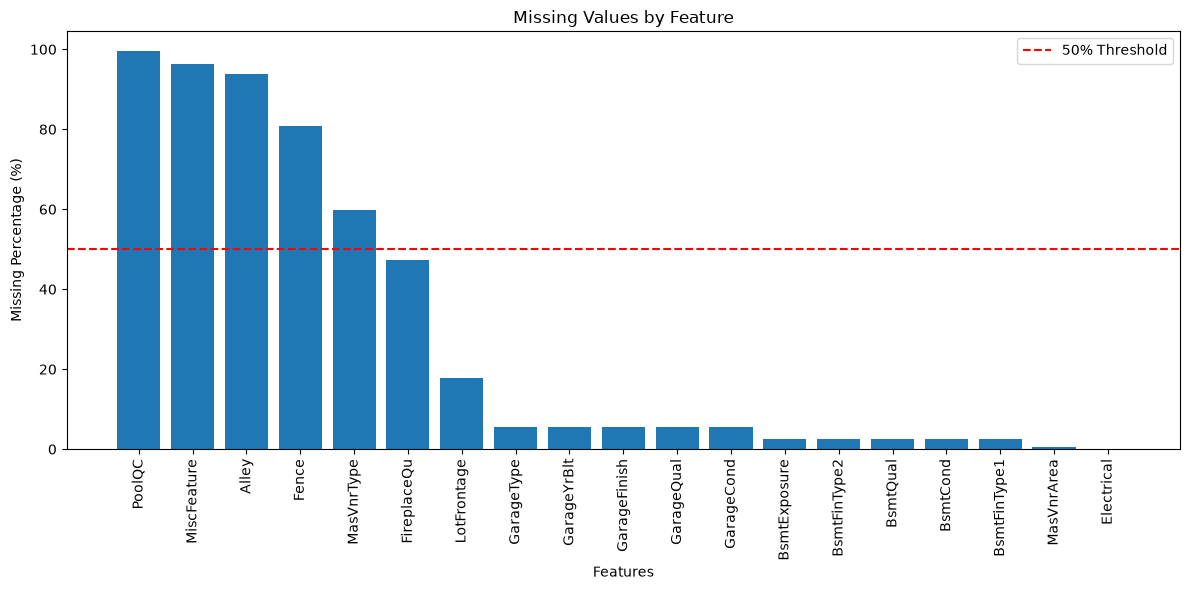

In [15]:
# ==================================================
# Visualize Missing Values
# ==================================================

plt.figure(figsize=(12, 6))

plt.bar(
    missing_summary["Column"],
    missing_summary["Missing_Percentage"]
)

plt.xticks(rotation=90)

plt.xlabel("Features")
plt.ylabel("Missing Percentage (%)")
plt.title("Missing Values by Feature")

plt.axhline(
    y=50,
    color="red",
    linestyle="--",
    label="50% Threshold"
)

plt.legend()

plt.tight_layout()

plt.show()

In [26]:
# ==================================================
# Drop Features with High Missing Rate (>50%)
# ==================================================

features_to_drop = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence"
]

Notebook1_df = Notebook1_df.drop(columns=features_to_drop)

print(f"Dropped {len(features_to_drop)} features.\n")

print("Dropped Features:")
for feature in features_to_drop:
    print(f"- {feature}")

print("\nNew Dataset Shape:", Notebook1_df.shape)

Dropped 4 features.

Dropped Features:
- PoolQC
- MiscFeature
- Alley
- Fence

New Dataset Shape: (1460, 77)


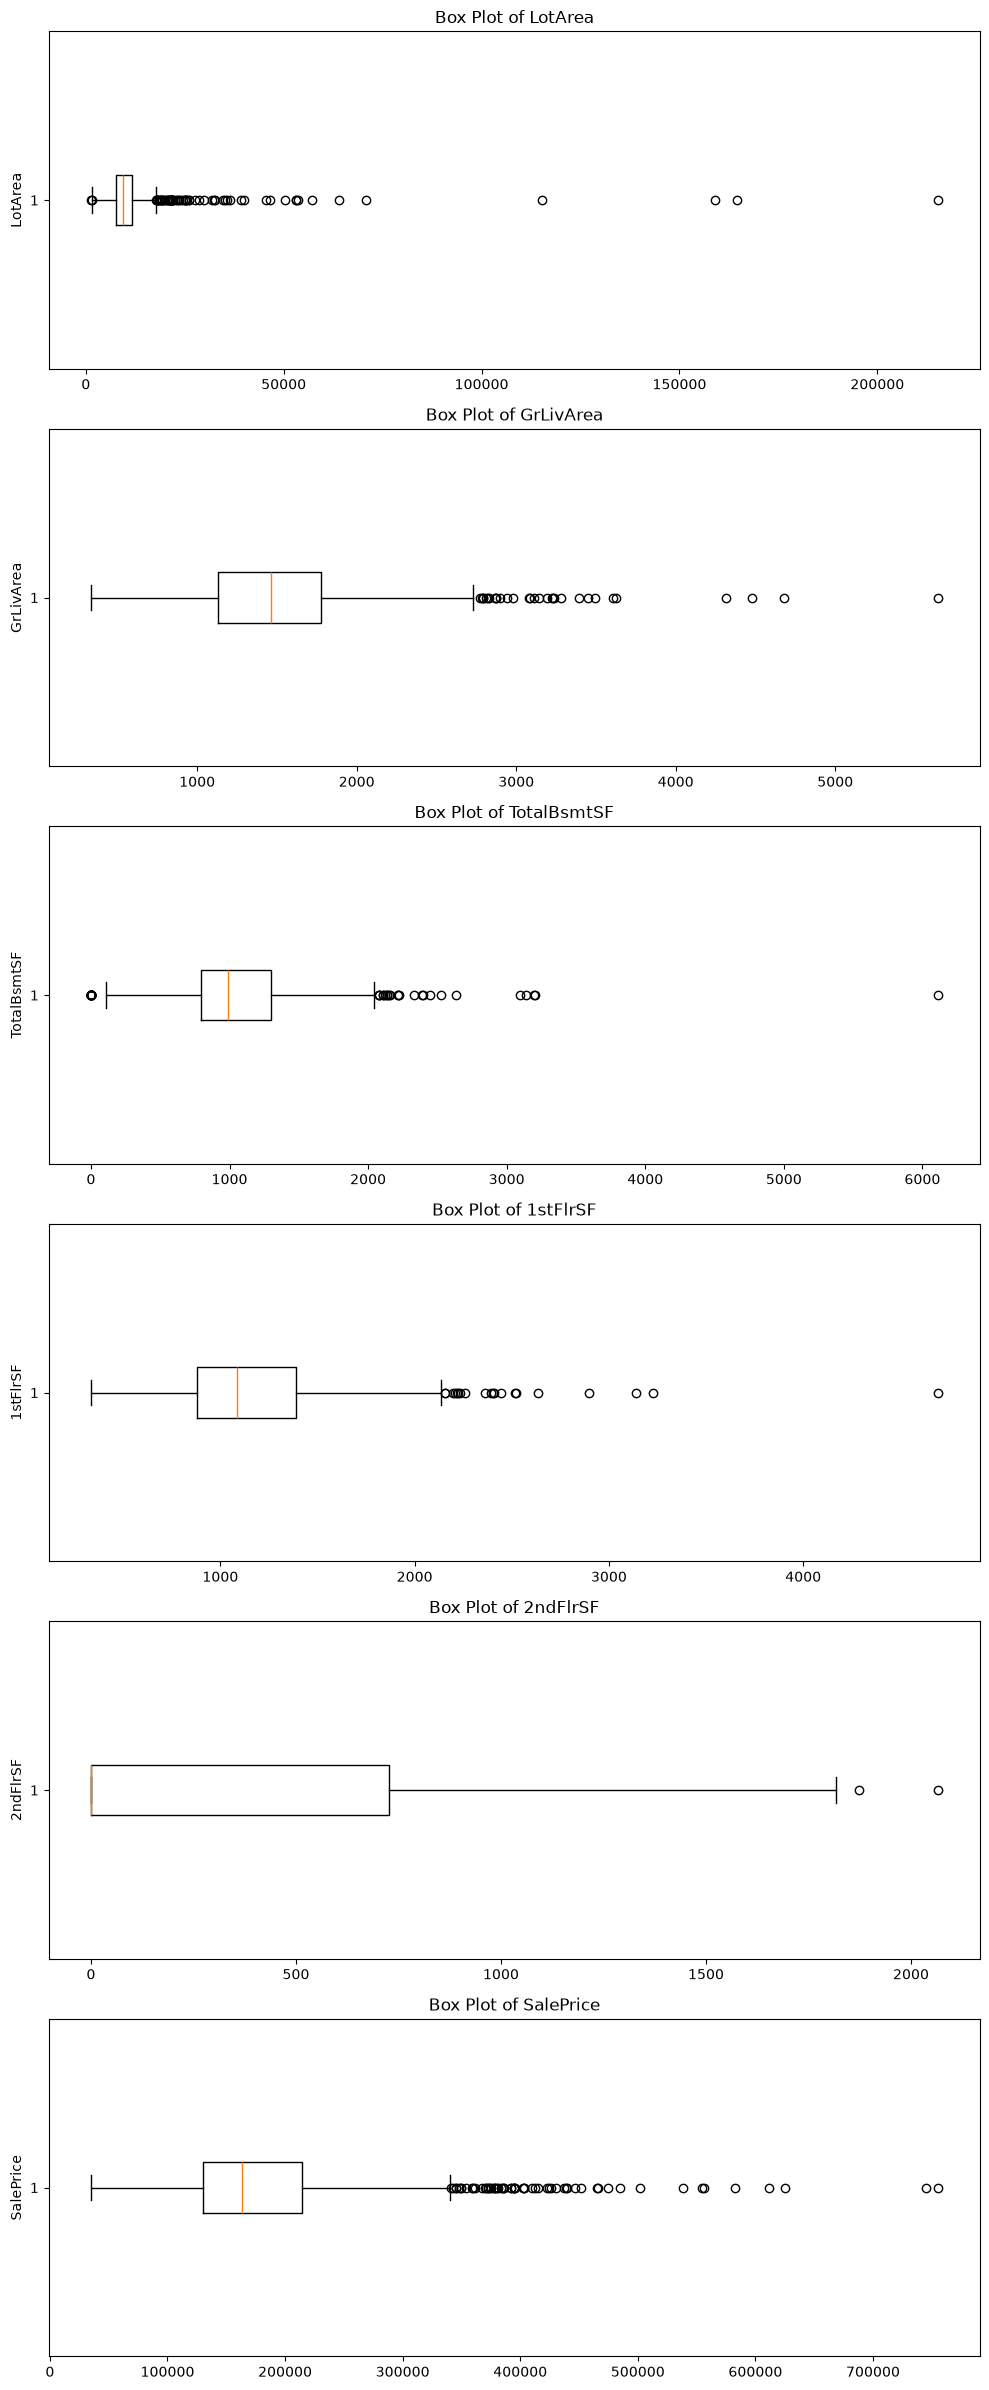

In [ ]:
# ==================================================
# Outlier Analysis
# ==================================================

# Key numerical features for outlier analysis
key_numeric_features = [
    "LotArea",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "SalePrice"
]
# Keep only existing columns
key_numeric_features = [
    col for col in key_numeric_features
    if col in Notebook1_df.columns
]

# ==================================================
# Box Plots
# ==================================================

ffig, axes = plt.subplots(
    len(key_numeric_features),
    1,
    figsize=(10, 4 * len(key_numeric_features))
)

if len(key_numeric_features) == 1:
    axes = [axes]

for i, col in enumerate(key_numeric_features):
    axes[i].boxplot(
        Notebook1_df[col].dropna(),
        orientation="horizontal"
    )
    axes[i].set_title(f"Box Plot of {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()



## Outlier Analysis

### Question

#Do the key numerical features contain potential outliers?

### Observation

#I used Box plots to visualize potential outliers in the selected numerical features.

### Decision

#No outliers were removed during the data cleaning stage. 
# Different outlier handling strategies will be evaluated during preprocessing using cross-validation and 
# XGBoost performance.

In [20]:
# ==================================================
# Detect Outliers Using IQR Method
# ==================================================

def detect_outliers_iqr(dataframe, column):
    """
    Detect outliers using the IQR method.

    Returns:
        outliers      : DataFrame containing outlier rows
        lower_bound   : Lower IQR boundary
        upper_bound   : Upper IQR boundary
    """

    Q1 = np.percentile(dataframe[column].dropna(), 25)
    Q3 = np.percentile(dataframe[column].dropna(), 75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = dataframe[
        (dataframe[column] < lower_bound) |
        (dataframe[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound

# ==================================================
# Apply IQR Method
# ==================================================

for col in key_numeric_features:

    outliers, lower_bound, upper_bound = detect_outliers_iqr(df, col)

    print("=" * 50)
    print(f"Feature: {col}")
    print(f"Lower Bound : {lower_bound:.2f}")
    print(f"Upper Bound : {upper_bound:.2f}")
    print(f"Number of Outliers : {len(outliers)}")

## IQR Outlier Analysis

### Observation

#Potential outliers were identified using the Interquartile Range (IQR) method.

### Decision

#No outliers were removed at this stage. The impact of removing or retaining outliers will be 
# evaluated during preprocessing using cross-validation and XGBoost performance.



## Outlier Analysis Summary

### Observation Notes

#Potential outliers were detected in several numerical features using the IQR method.

#The highest number of outliers was observed in:

#- LotArea
#- TotalBsmtSF
#- SalePrice
#- GrLivArea

### Decision

#I removed any outliers during the data cleaning stage.

#Outlier removal will be evaluated experimentally during preprocessing using cross-validation with XGBoost.

Feature: LotArea
Lower Bound : 1481.50
Upper Bound : 17673.50
Number of Outliers : 69
Feature: GrLivArea
Lower Bound : 158.62
Upper Bound : 2747.62
Number of Outliers : 31
Feature: TotalBsmtSF
Lower Bound : 42.00
Upper Bound : 2052.00
Number of Outliers : 61
Feature: 1stFlrSF
Lower Bound : 118.12
Upper Bound : 2155.12
Number of Outliers : 20
Feature: 2ndFlrSF
Lower Bound : -1092.00
Upper Bound : 1820.00
Number of Outliers : 2
Feature: SalePrice
Lower Bound : 3937.50
Upper Bound : 340037.50
Number of Outliers : 61


In [ ]:
# ==================================================
# Examine Extreme Living Area Properties
# ==================================================

extreme_area = Notebook1_df[Notebook1_df["GrLivArea"] > 4000]

print(extreme_area[
    [
        "Id",
        "GrLivArea",
        "SalePrice",
        "OverallQual",
        "OverallCond"
    ]
])

print(f"\nNumber of extreme properties: {len(extreme_area)}")

        Id  GrLivArea  SalePrice  OverallQual  OverallCond
523    524       4676     184750           10            5
691    692       4316     755000           10            6
1182  1183       4476     745000           10            5
1298  1299       5642     160000           10            5

Number of extreme properties: 4


In [27]:
# ==================================================
# Final Dataset Verification
# ==================================================

print("=" * 50)
print("DATA CLEANING SUMMARY")
print("=" * 50)

print(f"Original Shape : {Notebook1_df.shape}")
print(f"Current Shape  : {Notebook1_df.shape}")

print(f"\nRows Removed    : 0")
print(f"Columns Removed : 0")

remaining_missing = Notebook1_df.isnull().sum().sum()

print(f"\nRemaining Missing Values : {remaining_missing}")

print("\nData Types:")

print(Notebook1_df.dtypes.value_counts())

DATA CLEANING SUMMARY
Original Shape : (1460, 77)
Current Shape  : (1460, 77)

Rows Removed    : 0
Columns Removed : 0

Remaining Missing Values : 2422

Data Types:
str        39
int64      35
float64     3
Name: count, dtype: int64


In [ ]:
Notebook1_df.to_csv("../Outputs/pipeline1_clean.csv", index=False)

print("Pipeline 1 dataset saved successfully.")

Pipeline 1 dataset saved successfully.
